In [119]:
import math
import os
import os.path as osp
import shutil

import cv2
import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import random
import torch
import torch.nn.functional as F
import umap
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity


In [120]:
npz_path = "../data/mvtec_ad/embeddings/supcon_dataset_val-3.npz"
data = np.load(npz_path)
embeddings = data['embeddings']
instance_ids = data['instance_ids']

In [121]:
instance_ids.tolist()
instance_labels = ['_'.join(iid.split('_')[:-1]) for iid in instance_ids]
unique_labels = list(set(instance_labels))
sorted(unique_labels)

['bottle_broken_large',
 'bottle_broken_small',
 'bottle_contamination',
 'cable_bent_wire',
 'cable_cable_swap',
 'cable_combined',
 'cable_cut_inner_insulation',
 'cable_cut_outer_insulation',
 'cable_missing_cable',
 'cable_missing_wire',
 'cable_poke_insulation',
 'capsule_crack',
 'capsule_faulty_imprint',
 'capsule_poke',
 'capsule_scratch',
 'capsule_squeeze',
 'carpet_color',
 'carpet_cut',
 'carpet_hole',
 'carpet_metal_contamination',
 'carpet_thread',
 'grid_broken',
 'grid_glue',
 'grid_metal_contamination',
 'grid_thread',
 'hazelnut_crack',
 'hazelnut_cut',
 'hazelnut_hole',
 'hazelnut_print',
 'leather_color',
 'leather_cut',
 'leather_fold',
 'leather_glue',
 'leather_poke',
 'metal_nut_bent',
 'metal_nut_color',
 'metal_nut_flip',
 'metal_nut_scratch',
 'pill_color',
 'pill_combined',
 'pill_contamination',
 'pill_crack',
 'pill_faulty_imprint',
 'pill_pill_type',
 'pill_scratch',
 'screw_manipulated_front',
 'screw_scratch_head',
 'screw_scratch_neck',
 'screw_thread_

In [128]:
selected_embeddings = []
selected_labels = []
for emb, lb in zip(embeddings, instance_labels):
    if lb.startswith("carpet"):
        selected_embeddings.append(emb)
        selected_labels.append(lb)

selected_embeddings = np.stack(selected_embeddings)
print(f"selected_embeddings shape: {selected_embeddings.shape}")
print(f"selected_labels: {set(selected_labels)}")

selected_embeddings shape: (18, 128)
selected_labels: {'carpet_cut', 'carpet_thread', 'carpet_metal_contamination', 'carpet_hole', 'carpet_color'}


Total unique labels: 5


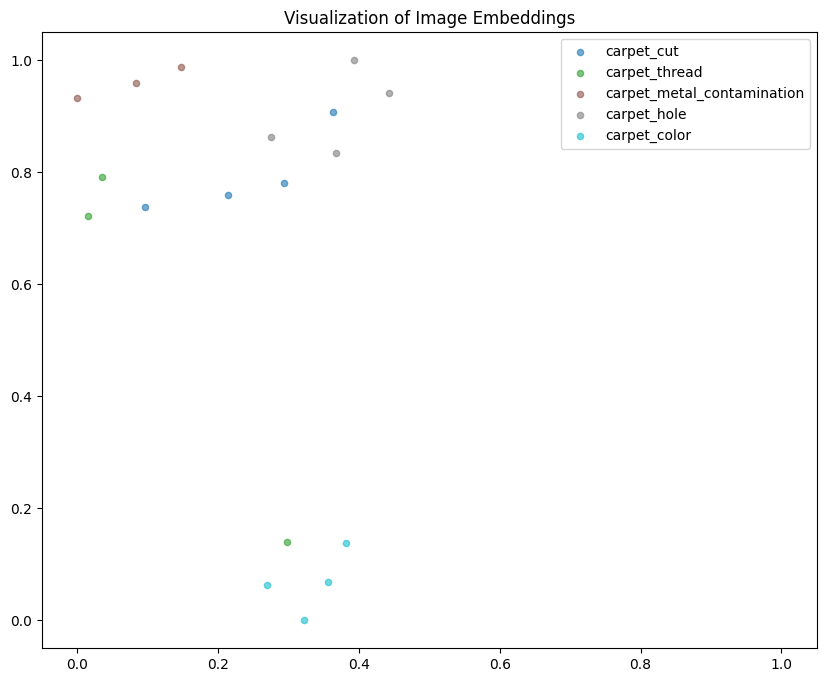

In [129]:
reducer = TSNE(
    n_components=2,
    perplexity=5,
    metric='cosine',
    random_state=42,
)
# reducer = umap.UMAP(
#     n_components=2,
#     random_state=42,
#     metric='cosine',
# )

embeddings_2d = reducer.fit_transform(selected_embeddings)
# 先将数据移到原点
embeddings_2d[:, 0] = embeddings_2d[:, 0] - embeddings_2d[:, 0].min()
embeddings_2d[:, 1] = embeddings_2d[:, 1] - embeddings_2d[:, 1].min()

# 找到最大的范围作为缩放基准
range_x = embeddings_2d[:, 0].max()
range_y = embeddings_2d[:, 1].max()
max_range = max(range_x, range_y)

# 按照最大范围等比例缩放到 [0, 1]
if max_range > 0:
    embeddings_2d = embeddings_2d / max_range

# 可视化embeddings
unique_selected_labels = list(set(selected_labels))
print(f"Total unique labels: {len(unique_selected_labels)}")

# 使用更大的色彩映射或生成随机颜色
if len(unique_selected_labels) <= 10:
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_selected_labels)))
else:
    # 方案1: 使用hsv色彩空间生成足够多的颜色
    colors = plt.cm.hsv(np.linspace(0, 1, len(unique_selected_labels)))

label_to_color = dict(zip(unique_selected_labels, colors))

plt.figure(figsize=(10, 8))
for label in unique_selected_labels:
    mask = np.array([l == label for l in selected_labels])
    plt.scatter(
        embeddings_2d[mask, 0], 
        embeddings_2d[mask, 1],
        c=[label_to_color[label]],
        label=label,
        alpha=0.6,
        s=20
    )

plt.legend()
plt.title("Visualization of Image Embeddings")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.show()